# Context
* "Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs."

In [2]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# reading the dataset

tel_df = pd.read_csv('./Telco-Customer.csv')
tel_df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3608,3208-YPIOE,Male,0,No,No,39,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Electronic check,75.25,3017.65,Yes
5596,5982-XMDEX,Female,0,No,No,65,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),26.50,1698.55,No
3279,6064-PUPMC,Male,0,Yes,Yes,23,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,No,Credit card (automatic),57.20,1423.35,No
5383,2362-IBOOY,Male,0,No,No,36,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,84.75,3050.15,Yes
200,9323-HGFWY,Female,0,Yes,No,27,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,Yes,One year,Yes,Credit card (automatic),101.90,2681.15,No
770,7706-DZNKK,Male,0,No,No,11,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Credit card (automatic),20.45,237.3,No
6414,3472-QPRCH,Male,0,Yes,Yes,40,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),25.25,1006.9,No
545,7129-AZJDE,Male,0,Yes,Yes,34,Yes,No,Fiber optic,No,...,No,No,No,Yes,One year,Yes,Bank transfer (automatic),78.95,2647.2,No
3050,0876-WDUUZ,Female,0,No,No,5,Yes,No,Fiber optic,No,...,No,Yes,No,Yes,Month-to-month,Yes,Credit card (automatic),85.40,425.9,Yes
4730,7813-ZGGAW,Male,1,No,No,31,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,No,Month-to-month,Yes,Bank transfer (automatic),96.60,2877.95,No


In [4]:
tel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# The data set includes information about:

* Customers who left within the last month – the column is called Churn

* Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies

* Customer account information - how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges

* Demographic info about customers – gender, age range, and if they have partners and dependents

In [5]:
# checking for null values
tel_df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

* OBSERVATION - We do not have any null values in this dataset

* OBSERVATION : AS WE CAN SEE MANY NUMBER OF COLUMNS HAS VALUES LIKE 'YES' AND 'NO'. WE NEED TO TURN THEM INTO NUMERIC. HENCE WE CAN USE MAPPING HERE 

In [6]:
column = tel_df.columns

for col in tel_df.columns:
    if tel_df[col].isin(['Yes', 'No']).any():
        print(col)

Partner
Dependents
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
PaperlessBilling
Churn


In [7]:
categorical_cols = tel_df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    unique_vals = tel_df[col].dropna().unique()
    
    if set(unique_vals).issubset({'Yes', 'No'}):
        print(f"Column: {col}")
        print(f"Unique: {unique_vals}")
        print("\n")

Column: Partner
Unique: ['Yes' 'No']


Column: Dependents
Unique: ['No' 'Yes']


Column: PhoneService
Unique: ['No' 'Yes']


Column: PaperlessBilling
Unique: ['Yes' 'No']


Column: Churn
Unique: ['No' 'Yes']




In [8]:
def mapping(df, col):
    mapping_code = {'No' : 0, 'Yes' : 1}
    df[col] = df[col].map(mapping_code)

In [9]:
mapping(tel_df,'Partner')
mapping(tel_df,'Dependents')
mapping(tel_df,'PhoneService')
mapping(tel_df,'Churn')

In [10]:
mapping(tel_df,'PaperlessBilling')

In [11]:
categorical_cols = tel_df.select_dtypes(include = 'object').columns.tolist()

for cols in categorical_cols :
    unique_vals = tel_df[cols].dropna().unique()
    
    if set(unique_vals).issubset({'Yes','No','No internet service'}):
        print(f'Column : {cols}')
        print(f'Unique : {unique_vals}')

Column : OnlineSecurity
Unique : ['No' 'Yes' 'No internet service']
Column : OnlineBackup
Unique : ['Yes' 'No' 'No internet service']
Column : DeviceProtection
Unique : ['No' 'Yes' 'No internet service']
Column : TechSupport
Unique : ['No' 'Yes' 'No internet service']
Column : StreamingTV
Unique : ['No' 'Yes' 'No internet service']
Column : StreamingMovies
Unique : ['No' 'Yes' 'No internet service']


In [12]:
def clean_and_map(df,cols) :
    df[cols] = df[cols].replace('No internet service','No')
    mapping(df,cols)

In [13]:
clean_and_map(tel_df,'OnlineSecurity')
clean_and_map(tel_df,'OnlineBackup')
clean_and_map(tel_df,'DeviceProtection')
clean_and_map(tel_df,'TechSupport')
clean_and_map(tel_df,'StreamingTV')
clean_and_map(tel_df,'StreamingMovies')

# CHECKING FOR MORE COLUMNS THAT MIGHT NEED MAPPING

In [14]:
for cols in categorical_cols:
    uni = tel_df[cols].unique()
    print(f'Column : {cols}')
    print(f"Unique : {uni}")

Column : customerID
Unique : ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
Column : gender
Unique : ['Female' 'Male']
Column : MultipleLines
Unique : ['No phone service' 'No' 'Yes']
Column : InternetService
Unique : ['DSL' 'Fiber optic' 'No']
Column : OnlineSecurity
Unique : [0 1]
Column : OnlineBackup
Unique : [1 0]
Column : DeviceProtection
Unique : [0 1]
Column : TechSupport
Unique : [0 1]
Column : StreamingTV
Unique : [0 1]
Column : StreamingMovies
Unique : [0 1]
Column : Contract
Unique : ['Month-to-month' 'One year' 'Two year']
Column : PaymentMethod
Unique : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Column : TotalCharges
Unique : ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']


# OBSERVATION :
* CUSTOMER ID IS NOT NEEDED WE CAN DROP IT
* WE NEED TO MAP THE GENDER COLUMN AND MULTIPLE LINES
* WE HAVE COLUMNS LIKE CONTRACT , PAYMENT-MODE AND INTERNET SERVICE  WHICH ALSO NEED ENCODING
* WE NEED TO TURN THE COLUMN TOTAL CHARGES INTO INT64

In [15]:
tel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   int64  


In [16]:
# DROPPING CUSTOMER ID
tel_df.drop('customerID',inplace = True, axis = 1)

In [17]:
# mapping 
gender_code = {'Male' : 0 , 'Female' : 1}
tel_df['gender'] = tel_df['gender'].map(gender_code)

In [18]:
tel_df['gender'].unique()

array([1, 0])

In [19]:
# replacing and mapping MultipleLines

tel_df['MultipleLines'] = tel_df['MultipleLines'].replace('No phone service','No')
mapping_code = {'No' : 0, 'Yes' : 1}
tel_df['MultipleLines'] = tel_df['MultipleLines'].map(mapping_code)
tel_df['MultipleLines'].unique()

array([0, 1])

* WE HAVE COLUMNS LIKE CONTRACT , PAYMENT-MODE AND INTERNET SERVICE WHERE MAPPING WOULD BE LOGICAL ERROR. SO WE WILL USE ONE-HOT-ENCODER

In [20]:
from sklearn.preprocessing import OneHotEncoder

e_columns = ['Contract','PaymentMethod','InternetService']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_data = encoder.fit_transform(tel_df[e_columns])
encoded_cols = encoder.get_feature_names_out(e_columns)

encoded_df = pd.DataFrame(encoded_data, columns=encoded_cols)

tel_df = pd.concat([tel_df, encoded_df], axis=1)
tel_df.drop(e_columns, axis=1, inplace=True)

In [21]:
tel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   OnlineSecurity                           7043 non-null   int64  
 8   OnlineBackup                             7043 non-null   int64  
 9   DeviceProtection                         7043 non-null   int64  
 10  TechSupport                              7043 no

In [22]:
# now changing the column total charges into int64

tel_df['TotalCharges'] = pd.to_numeric(tel_df['TotalCharges'], errors='coerce')

In [23]:
# checking for null values
tel_df['TotalCharges'].isna().sum()

np.int64(11)

<Axes: >

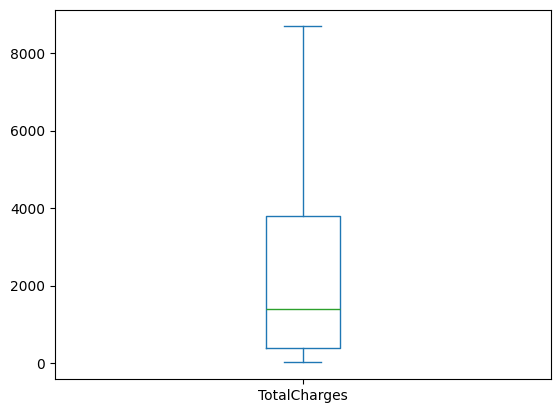

In [24]:
tel_df['TotalCharges'].plot(kind = 'box')

* observation : No outliers so we use mean here

In [25]:
tel_df['TotalCharges'] = tel_df['TotalCharges'].fillna(tel_df['TotalCharges'].mean())

In [26]:
tel_df.isna().sum()

gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
MultipleLines                              0
OnlineSecurity                             0
OnlineBackup                               0
DeviceProtection                           0
TechSupport                                0
StreamingTV                                0
StreamingMovies                            0
PaperlessBilling                           0
MonthlyCharges                             0
TotalCharges                               0
Churn                                      0
Contract_Month-to-month                    0
Contract_One year                          0
Contract_Two year                          0
PaymentMethod_Bank transfer (automatic)    0
PaymentMethod_Credit card (automatic)      0
PaymentMet

* NO NULL VALUES DETECTED

# TRAINING THE MODEL

In [27]:
X = tel_df.drop('Churn', axis = 1)
Y = tel_df['Churn']

print(X.shape)
print(Y.shape)

(7043, 26)
(7043,)


* IT IS A SMALL DATASET SO I AM DIVIDING IT ONLY INTO TEST AND TRAIN

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.25, random_state=42)

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(5282, 26)
(5282,)
(1761, 26)
(1761,)


* TRAINING THE MODEL USING DECISION TREE : 1. FINDING THE DEPTH, 2. TRAINING THE MODEL 3. FINDING THE IMPORTANT FEATURES

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
def depth(md) :
    model = DecisionTreeClassifier(max_depth = md, random_state = 42)
    model.fit(X_train, Y_train)
    train_error = 1 - model.score(X_train,Y_train)
    Y_pred = model.predict(X_test)
    Accuracy = accuracy_score(Y_test,Y_pred)

    return{
        'Max_Depth' : md,
        'Train_error' : train_error,
        'Accuracy' : Accuracy
    }

In [30]:
error = pd.DataFrame([
    depth(md)
    for md in range(1,21)
])
error

,Max_Depth,Train_error,Accuracy
0,1,0.263158,0.727995
1,2,0.241007,0.772856
2,3,0.208633,0.787053
3,4,0.206929,0.783078
4,5,0.198788,0.786485
5,6,0.191215,0.784781
6,7,0.175691,0.787053
7,8,0.161681,0.773992
8,9,0.141234,0.779671
9,10,0.123438,0.762635


In [31]:
model = DecisionTreeClassifier(max_depth = 7, random_state=42)
model.fit(X_train,Y_train)
model.score(X_train,Y_train)

0.8243089738735327

In [32]:
model.score(X_test,Y_test)

0.787052810902896

In [33]:
importance_df = pd.DataFrame({
  'feature' : X_train.columns,
  'importance' : model.feature_importances_
}).sort_values('importance', ascending=False)

In [34]:
importance_df.head(10)

,feature,importance
16,Contract_Month-to-month,0.413593
4,tenure,0.174478
24,InternetService_Fiber optic,0.113172
14,MonthlyCharges,0.102084
15,TotalCharges,0.075356
21,PaymentMethod_Electronic check,0.022337
6,MultipleLines,0.018201
12,StreamingMovies,0.012829
1,SeniorCitizen,0.010263
5,PhoneService,0.010108


<Axes: title={'center': 'Feature Importance'}, xlabel='importance', ylabel='feature'>

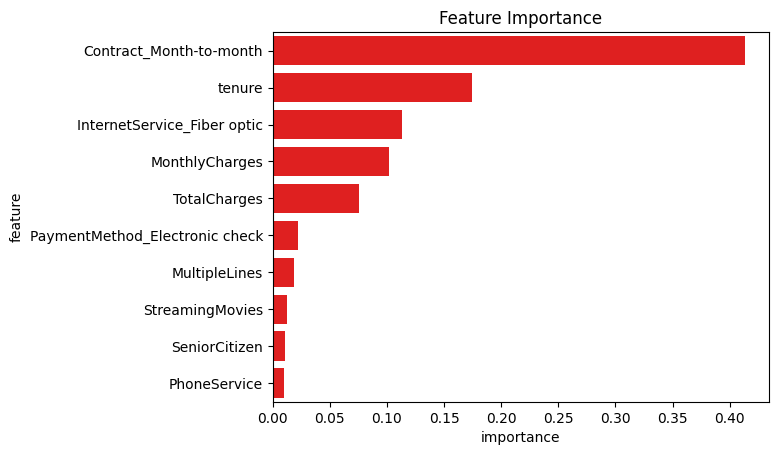

In [35]:
plt.title("Feature Importance")
sns.barplot(data=importance_df.head(10), x='importance',y='feature',color='red')

# TRAINING A RANDOM FOREST MODEL WITH DIFFERENT PARAMETERS

In [38]:
from sklearn.ensemble import RandomForestClassifier
def training(**params) :
    model = RandomForestClassifier(random_state=42, n_jobs=-1,**params).fit(X_train,Y_train)
    train_score = model.score(X_train,Y_train)
    test_score = model.score(X_test,Y_test)
    prediction = model.predict(X_test)
    return {
        'TRAINING_SCORE' : train_score,
        'TEST_SCORE' : test_score,
    }

In [39]:
training(max_depth = 5)

{'TRAINING_SCORE': 0.8017796289284362, 'TEST_SCORE': 0.7927314026121521}

In [40]:
training(max_depth = 25)

{'TRAINING_SCORE': 0.998485422188565, 'TEST_SCORE': 0.7898921067575241}

In [41]:
training(max_features = 3)

{'TRAINING_SCORE': 0.998485422188565, 'TEST_SCORE': 0.7842135150482681}

In [42]:
model2 = RandomForestClassifier(random_state=42, n_jobs = -1 , max_depth= 25)
model2.fit(X_train,Y_train)
model2.score(X_train,Y_train)

0.998485422188565

In [43]:
model2.score(X_test,Y_test)

0.7898921067575241

In [45]:
# FEATURE IMPORTANCE
importance = pd.DataFrame({
  'features' : X_train.columns,
  'importance' : model.feature_importances_
}).sort_values('importance',ascending=False)

importance.head(10)

,features,importance
16,Contract_Month-to-month,0.413593
4,tenure,0.174478
24,InternetService_Fiber optic,0.113172
14,MonthlyCharges,0.102084
15,TotalCharges,0.075356
21,PaymentMethod_Electronic check,0.022337
6,MultipleLines,0.018201
12,StreamingMovies,0.012829
1,SeniorCitizen,0.010263
5,PhoneService,0.010108


<Axes: title={'center': 'RANDOM FOREST FEATURE IMPORTANCE'}, xlabel='importance', ylabel='features'>

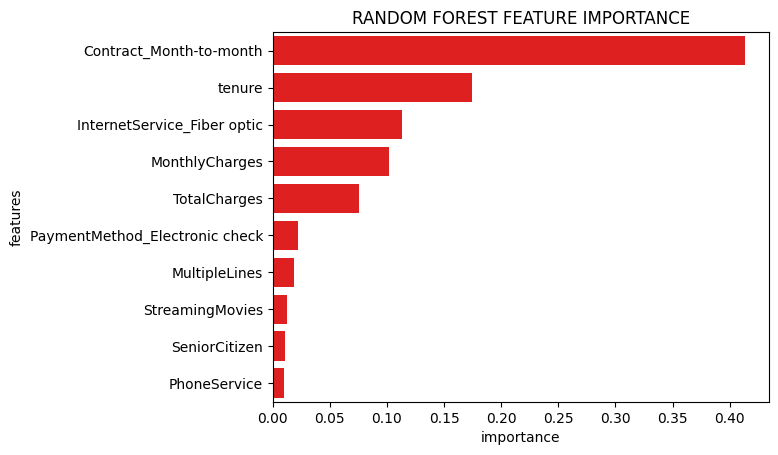

In [48]:
plt.title('RANDOM FOREST FEATURE IMPORTANCE')
sns.barplot(data = importance.head(10), y = 'features', x = 'importance', color = 'red')